In [47]:
import numpy as np
import pandas as pd
import random
from chemevo import evolution_V1 as evo
import itertools
import os
import matplotlib.pyplot as plt


fe_mg_bin_edges = np.arange(-0.35, 0.15, 0.1)
fe_mg_centers = 0.5 * (fe_mg_bin_edges[:-1] + fe_mg_bin_edges[1:])

In [48]:
data = pd.read_csv("data_lines_with_vals.csv")

In [49]:
from chemevo import iterative_1D_method

In [50]:
#etas_alter = [0, 0.1, 0.2, 0.5, 1, 2]
#tau_stars_alter = [1, 2, 3, 4, 5, 10]

etas_alter =np.logspace(-2, 1, 10)
tau_stars_alter =np.linspace(0.5, 6, 10)

## initi values: alpha_cc = 0.3, alpha_Ia = 0.4, g_cc = 0.4, g_ratio = 1.8

In [51]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="nopenalty_1/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.3,
                                      alpha_Ia_init=0.4, g_cc_init=0.4, g_ratio_init=1.8)

alpha_ccs =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_cc =  300
n_gals total =  1500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.0999999999999999
alpha_Ias =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each alpha_Ia =  300
n_gals total =  900
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best

In [52]:
best_per_iter = pd.read_csv("nopenalty_1/best_parameters_per_iteration.csv")
best_per_iter

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.1,0.4,0.4,1.8
1,0,0.1,0.6,0.4,1.8
2,0,0.1,0.6,0.3,1.8
3,0,0.1,0.6,0.3,2.0
4,1,0.1,0.6,0.3,2.0
5,1,0.1,0.4,0.3,2.0
6,1,0.1,0.4,0.3,2.0
7,1,0.1,0.4,0.3,2.2
8,2,0.1,0.4,0.3,2.2
9,2,0.1,0.5,0.3,2.2


In [53]:
folder_path = "nopenalty_1/"

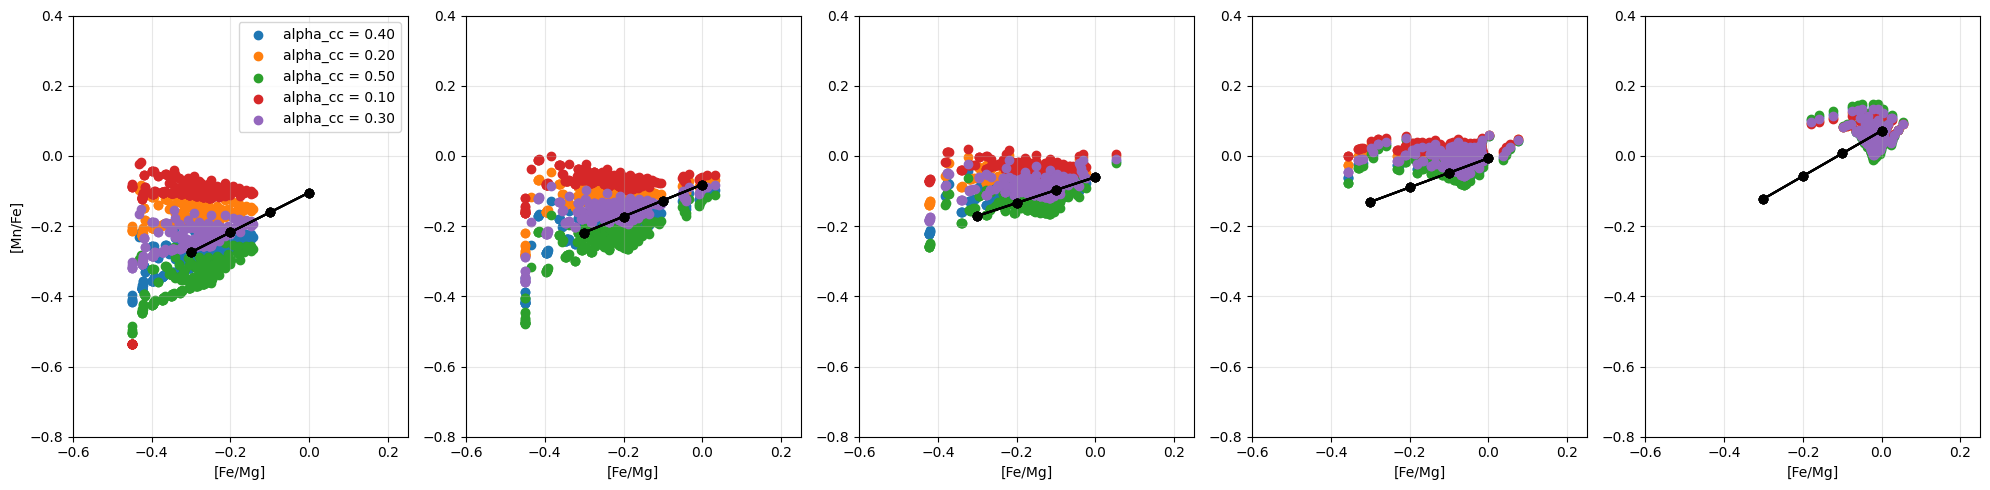

In [54]:
filepath_list = []
output_dfs = []

for filename in os.listdir(folder_path):
    if filename.startswith("alpha_cc_iter0") and filename.endswith(".csv"):
        filepath_list.append(folder_path+filename)
        df = pd.read_csv(folder_path+filename)
        output_dfs.append(df)


plt.figure(figsize=(20,5))

for i in range(len(output_dfs)):
    model_df = output_dfs[i]
    mg_h_bins = model_df['mg_h_bin'].unique()
    for j in range(len(mg_h_bins)):
        mg_h_bin = mg_h_bins[j]
        model_subset = model_df[np.isclose(model_df['mg_h_bin'], mg_h_bin)]
        data_subset = data[np.isclose(data['mg_h_bin_center'], mg_h_bin)]
        data_line_xs = fe_mg_centers
        data_line_ys = data_subset['slope_mn_fe'].iloc[0] * fe_mg_centers + data_subset['intercept_mn_fe'].iloc[0]
        plt.subplot(1,5,j+1)
        plt.plot(data_line_xs, data_line_ys, marker = 'o', color = 'black')
        plt.scatter(model_subset['fe_mg'], model_subset['mn_fe'], label = f'alpha_cc = {model_subset['alpha_cc'].iloc[0]:.2f}')
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.grid(True, alpha = 0.3)
        plt.xlabel("[Fe/Mg]")
        if j == 0:
            plt.ylabel("[Mn/Fe]")
            plt.legend()

plt.tight_layout()
plt.show()

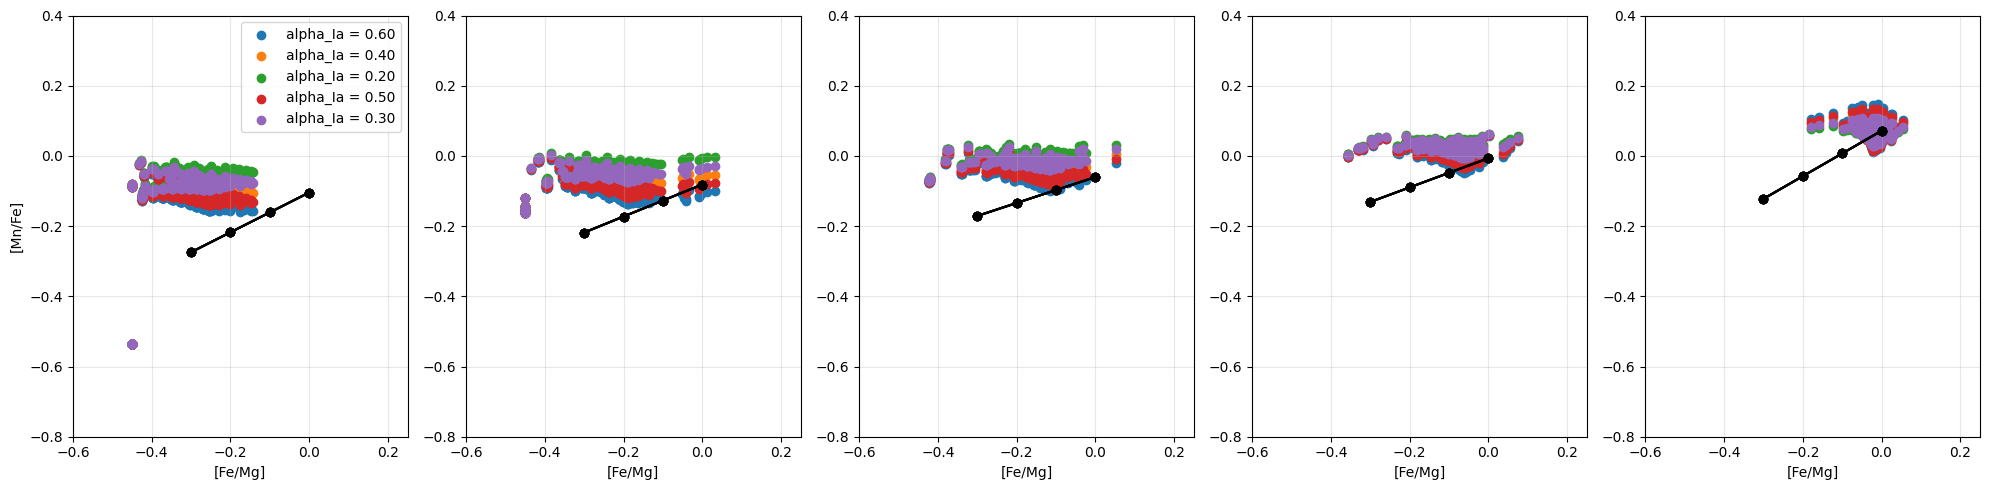

In [55]:
filepath_list = []
output_dfs = []

for filename in os.listdir(folder_path):
    if filename.startswith("alpha_Ia_iter0") and filename.endswith(".csv"):
        filepath_list.append(folder_path+filename)
        df = pd.read_csv(folder_path+filename)
        output_dfs.append(df)


plt.figure(figsize=(20,5))

for i in range(len(output_dfs)):
    model_df = output_dfs[i]
    mg_h_bins = model_df['mg_h_bin'].unique()
    for j in range(len(mg_h_bins)):
        mg_h_bin = mg_h_bins[j]
        model_subset = model_df[np.isclose(model_df['mg_h_bin'], mg_h_bin)]
        data_subset = data[np.isclose(data['mg_h_bin_center'], mg_h_bin)]
        data_line_xs = fe_mg_centers
        data_line_ys = data_subset['slope_mn_fe'].iloc[0] * fe_mg_centers + data_subset['intercept_mn_fe'].iloc[0]
        plt.subplot(1,5,j+1)
        plt.plot(data_line_xs, data_line_ys, marker = 'o', color = 'black')
        plt.scatter(model_subset['fe_mg'], model_subset['mn_fe'], label = f'alpha_Ia = {model_subset['alpha_Ia'].iloc[0]:.2f}')
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.grid(True, alpha = 0.3)
        plt.xlabel("[Fe/Mg]")
        if j == 0:
            plt.ylabel("[Mn/Fe]")
            plt.legend()

plt.tight_layout()
plt.show()

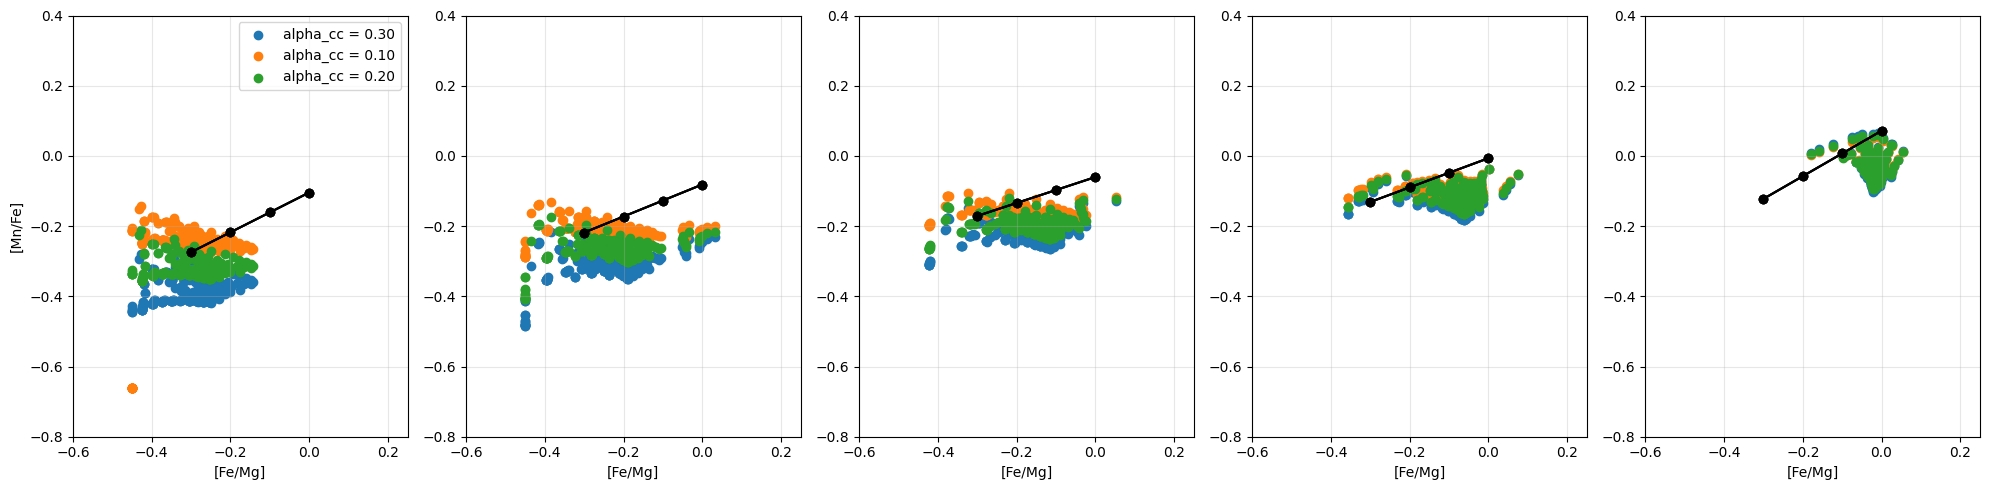

In [56]:
filepath_list = []
output_dfs = []

for filename in os.listdir(folder_path):
    if filename.startswith("alpha_cc_iter1") and filename.endswith(".csv"):
        filepath_list.append(folder_path+filename)
        df = pd.read_csv(folder_path+filename)
        output_dfs.append(df)


plt.figure(figsize=(20,5))

for i in range(len(output_dfs)):
    model_df = output_dfs[i]
    mg_h_bins = model_df['mg_h_bin'].unique()
    for j in range(len(mg_h_bins)):
        mg_h_bin = mg_h_bins[j]
        model_subset = model_df[np.isclose(model_df['mg_h_bin'], mg_h_bin)]
        data_subset = data[np.isclose(data['mg_h_bin_center'], mg_h_bin)]
        data_line_xs = fe_mg_centers
        data_line_ys = data_subset['slope_mn_fe'].iloc[0] * fe_mg_centers + data_subset['intercept_mn_fe'].iloc[0]
        plt.subplot(1,5,j+1)
        plt.plot(data_line_xs, data_line_ys, marker = 'o', color = 'black')
        plt.scatter(model_subset['fe_mg'], model_subset['mn_fe'], label = f'alpha_cc = {model_subset['alpha_cc'].iloc[0]:.2f}')
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.grid(True, alpha = 0.3)
        plt.xlabel("[Fe/Mg]")
        if j == 0:
            plt.ylabel("[Mn/Fe]")
            plt.legend()

plt.tight_layout()
plt.show()

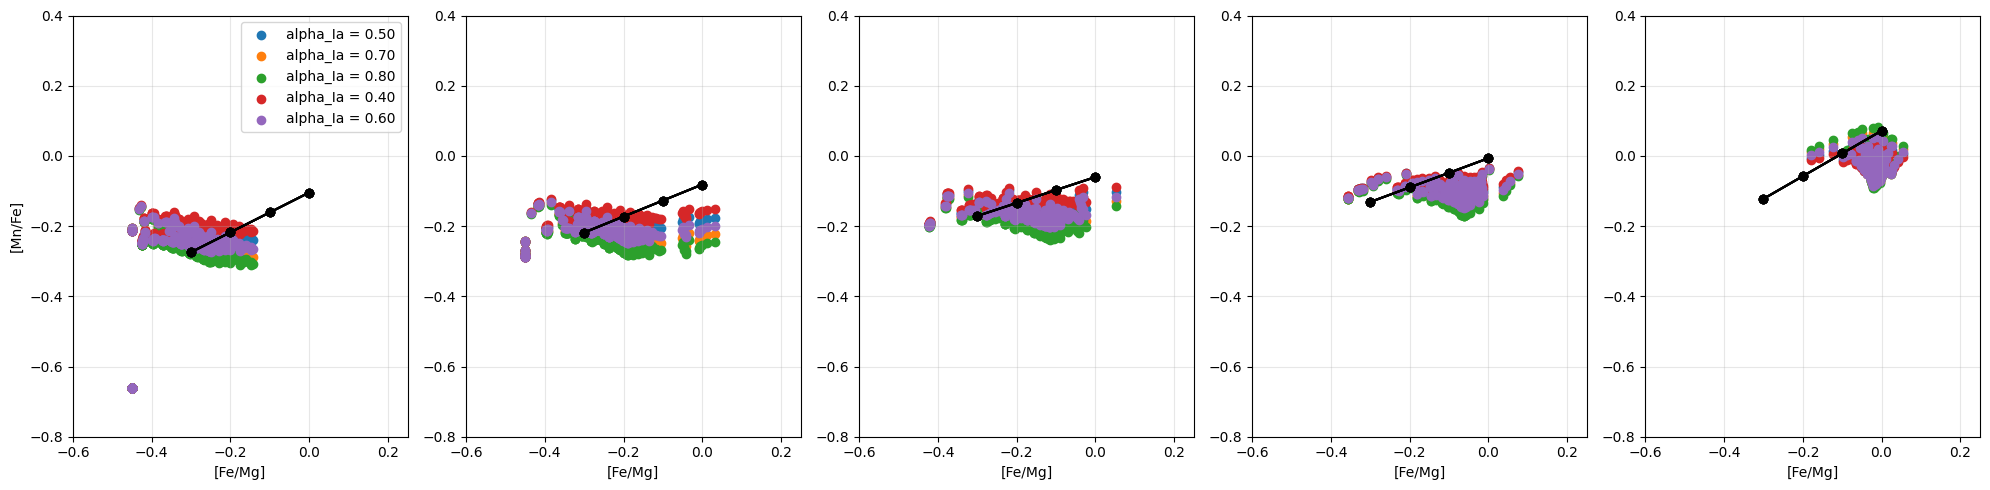

In [57]:
filepath_list = []
output_dfs = []

for filename in os.listdir(folder_path):
    if filename.startswith("alpha_Ia_iter1") and filename.endswith(".csv"):
        filepath_list.append(folder_path+filename)
        df = pd.read_csv(folder_path+filename)
        output_dfs.append(df)


plt.figure(figsize=(20,5))

for i in range(len(output_dfs)):
    model_df = output_dfs[i]
    mg_h_bins = model_df['mg_h_bin'].unique()
    for j in range(len(mg_h_bins)):
        mg_h_bin = mg_h_bins[j]
        model_subset = model_df[np.isclose(model_df['mg_h_bin'], mg_h_bin)]
        data_subset = data[np.isclose(data['mg_h_bin_center'], mg_h_bin)]
        data_line_xs = fe_mg_centers
        data_line_ys = data_subset['slope_mn_fe'].iloc[0] * fe_mg_centers + data_subset['intercept_mn_fe'].iloc[0]
        plt.subplot(1,5,j+1)
        plt.plot(data_line_xs, data_line_ys, marker = 'o', color = 'black')
        plt.scatter(model_subset['fe_mg'], model_subset['mn_fe'], label = f'alpha_Ia = {model_subset['alpha_Ia'].iloc[0]:.2f}')
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.grid(True, alpha = 0.3)
        plt.xlabel("[Fe/Mg]")
        if j == 0:
            plt.ylabel("[Mn/Fe]")
            plt.legend()

plt.tight_layout()
plt.show()

## initi values: alpha_cc = 0.3, alpha_Ia = 0.3, g_cc = 0.4, g_ratio = 1.8

In [58]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="nopenalty_2/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.3,
                                      alpha_Ia_init=0.3, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

alpha_ccs =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_cc =  300
n_gals total =  1500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.0999999999999999
alpha_Ias =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_Ia =  300
n_gals total =  900
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best

In [59]:
best_per_iter = pd.read_csv("nopenalty_2/best_parameters_per_iteration.csv")
best_per_iter

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.1,0.3,0.4,1.8
1,0,0.1,0.5,0.4,1.8
2,0,0.1,0.5,0.3,1.8
3,0,0.1,0.5,0.3,2.0
4,1,0.1,0.5,0.3,2.0
5,1,0.1,0.4,0.3,2.0
6,1,0.1,0.4,0.3,2.0
7,1,0.1,0.4,0.3,2.2
8,2,0.1,0.4,0.3,2.2
9,2,0.1,0.5,0.3,2.2


## initi values: alpha_cc = 0.6, alpha_Ia = 0.3, g_cc = 0.4, g_ratio = 1.8

In [60]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="nopenalty_3/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.6,
                                      alpha_Ia_init=0.3, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

alpha_ccs =  [0.4 0.5 0.6 0.7 0.8]
n_gals in each alpha_cc =  300
n_gals total =  1500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.3999999999999999
alpha_Ias =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_Ia =  300
n_gals total =  1500
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
bes

In [61]:
best_per_iter = pd.read_csv("nopenalty_3/best_parameters_per_iteration.csv")
best_per_iter

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.4,0.3,0.4,1.8
1,0,0.4,0.3,0.4,1.8
2,0,0.4,0.3,0.4,1.8
3,0,0.4,0.3,0.4,1.7
4,1,0.2,0.3,0.4,1.7
5,1,0.2,0.5,0.4,1.7
6,1,0.2,0.5,0.4,1.7
7,1,0.2,0.5,0.4,1.5
8,2,0.1,0.5,0.4,1.5
9,2,0.1,0.7,0.4,1.5


## initi values: alpha_cc = 0.4, alpha_Ia = 0.3, g_cc = 0.4, g_ratio = 1.8

In [62]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="nopenalty_4/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.4,
                                      alpha_Ia_init=0.3, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

alpha_ccs =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each alpha_cc =  300
n_gals total =  1500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.2
alpha_Ias =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_Ia =  300
n_gals total =  1200
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_Ia = 0.

In [63]:
best_per_iter = pd.read_csv("nopenalty_4/best_parameters_per_iteration.csv")
best_per_iter

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.2,0.3,0.4,1.8
1,0,0.2,0.5,0.4,1.8
2,0,0.2,0.5,0.4,1.8
3,0,0.2,0.5,0.4,1.6
4,1,0.1,0.5,0.4,1.6
5,1,0.1,0.7,0.4,1.6
6,1,0.1,0.7,0.4,1.6
7,1,0.1,0.7,0.4,1.4
8,2,0.1,0.7,0.4,1.4
9,2,0.1,0.9,0.4,1.4


## initi values: alpha_cc = 0.5, alpha_Ia = 0.3, g_cc = 0.4, g_ratio = 1.8

In [64]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="nopenalty_5/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.5,
                                      alpha_Ia_init=0.3, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

alpha_ccs =  [0.3 0.4 0.5 0.6 0.7]
n_gals in each alpha_cc =  300
n_gals total =  1500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.3
alpha_Ias =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_Ia =  300
n_gals total =  1500
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_Ia = 0.

In [65]:
best_per_iter = pd.read_csv("nopenalty_5/best_parameters_per_iteration.csv")
best_per_iter

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.3,0.3,0.4,1.8
1,0,0.3,0.5,0.4,1.8
2,0,0.3,0.5,0.4,1.8
3,0,0.3,0.5,0.4,1.7
4,1,0.1,0.5,0.4,1.7
5,1,0.1,0.7,0.4,1.7
6,1,0.1,0.7,0.3,1.7
7,1,0.1,0.7,0.3,1.9
8,2,0.1,0.7,0.3,1.9
9,2,0.1,0.5,0.3,1.9


## initi values: alpha_cc = 0.9, alpha_Ia = 0.3, g_cc = 0.4, g_ratio = 1.8

In [66]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="nopenalty_6/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.9,
                                      alpha_Ia_init=0.3, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

alpha_ccs =  [0.7 0.8 0.9 1.  1.1]
n_gals in each alpha_cc =  300
n_gals total =  1500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.7
alpha_Ias =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_Ia =  300
n_gals total =  1500
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_Ia = 0.

In [67]:
best_per_iter = pd.read_csv("nopenalty_6/best_parameters_per_iteration.csv")
best_per_iter

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.7,0.3,0.4,1.8
1,0,0.7,0.1,0.4,1.8
2,0,0.7,0.1,0.5,1.8
3,0,0.7,0.1,0.5,1.6
4,1,0.5,0.1,0.5,1.6
5,1,0.5,0.3,0.5,1.6
6,1,0.5,0.3,0.5,1.6
7,1,0.5,0.3,0.5,1.4
8,2,0.3,0.3,0.5,1.4
9,2,0.3,0.5,0.5,1.4


## initi values: alpha_cc = 0.29, alpha_Ia = 0.3, g_cc = 0.4, g_ratio = 1.8

In [68]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="nopenalty_7/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.29,
                                      alpha_Ia_init=0.3, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

alpha_ccs =  [0.09 0.19 0.29 0.39 0.49]
n_gals in each alpha_cc =  300
n_gals total =  1500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.1899999999999999
alpha_Ias =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_Ia =  300
n_gals total =  1200
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 

In [69]:
best_per_iter = pd.read_csv("nopenalty_7/best_parameters_per_iteration.csv")
best_per_iter

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.19,0.3,0.4,1.8
1,0,0.19,0.5,0.4,1.8
2,0,0.19,0.5,0.4,1.8
3,0,0.19,0.5,0.4,1.6
4,1,0.09,0.5,0.4,1.6
5,1,0.09,0.7,0.4,1.6
6,1,0.09,0.7,0.4,1.6
7,1,0.09,0.7,0.4,1.4
8,2,0.09,0.7,0.4,1.4
9,2,0.09,0.9,0.4,1.4


## initi values: alpha_cc = 0.25, alpha_Ia = 0.3, g_cc = 0.4, g_ratio = 1.8

In [70]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="nopenalty_8/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.25,
                                      alpha_Ia_init=0.3, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

alpha_ccs =  [0.05 0.15 0.25 0.35 0.45]
n_gals in each alpha_cc =  300
n_gals total =  1500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.0499999999999999
alpha_Ias =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_Ia =  300
n_gals total =  900
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0

In [71]:
best_per_iter = pd.read_csv("nopenalty_8/best_parameters_per_iteration.csv")
best_per_iter

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.05,0.3,0.4,1.8
1,0,0.05,0.5,0.4,1.8
2,0,0.05,0.5,0.3,1.8
3,0,0.05,0.5,0.3,2.0
4,1,0.05,0.5,0.3,2.0
5,1,0.05,0.6,0.3,2.0
6,1,0.05,0.6,0.3,2.0
7,1,0.05,0.6,0.3,2.1
8,2,0.05,0.6,0.3,2.1
9,2,0.05,0.6,0.3,2.1


## initi values: alpha_cc = 0.20, alpha_Ia = 0.3, g_cc = 0.4, g_ratio = 1.8

In [72]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="nopenalty_9/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.2,
                                      alpha_Ia_init=0.3, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

alpha_ccs =  [0.1 0.2 0.3 0.4]
n_gals in each alpha_cc =  300
n_gals total =  1200
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.1
alpha_Ias =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_Ia =  300
n_gals total =  900
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_Ia = 0.5
g_ccs =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each g_cc =  300
n_gals total =  900
Do

In [73]:
best_per_iter = pd.read_csv("nopenalty_9/best_parameters_per_iteration.csv")
best_per_iter

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.1,0.3,0.4,1.8
1,0,0.1,0.5,0.4,1.8
2,0,0.1,0.5,0.3,1.8
3,0,0.1,0.5,0.3,2.0
4,1,0.1,0.5,0.3,2.0
5,1,0.1,0.4,0.3,2.0
6,1,0.1,0.4,0.3,2.0
7,1,0.1,0.4,0.3,2.2
8,2,0.1,0.4,0.3,2.2
9,2,0.1,0.5,0.3,2.2


## initi values: alpha_cc = 0.30, alpha_Ia = 0.35, g_cc = 0.4, g_ratio = 1.8

In [74]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="nopenalty_10/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.30,
                                      alpha_Ia_init=0.35, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

alpha_ccs =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_cc =  300
n_gals total =  1500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.0999999999999999
alpha_Ias =  [0.15 0.25 0.35 0.45 0.55]
n_gals in each alpha_Ia =  300
n_gals total =  900
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0

In [75]:
best_per_iter = pd.read_csv("nopenalty_10/best_parameters_per_iteration.csv")
best_per_iter

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.1,0.35,0.4,1.8
1,0,0.1,0.55,0.4,1.8
2,0,0.1,0.55,0.3,1.8
3,0,0.1,0.55,0.3,2.0
4,1,0.1,0.55,0.3,2.0
5,1,0.1,0.45,0.3,2.0
6,1,0.1,0.45,0.3,2.0
7,1,0.1,0.45,0.3,2.2
8,2,0.1,0.45,0.3,2.2
9,2,0.1,0.45,0.3,2.2


## initi values: alpha_cc = 0.30, alpha_Ia = 0.40, g_cc = 0.4, g_ratio = 1.8

In [76]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="nopenalty_11/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.30,
                                      alpha_Ia_init=0.40, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

alpha_ccs =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_cc =  300
n_gals total =  1500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.0999999999999999
alpha_Ias =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each alpha_Ia =  300
n_gals total =  900
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best

In [77]:
best_per_iter = pd.read_csv("nopenalty_11/best_parameters_per_iteration.csv")
best_per_iter

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.1,0.4,0.4,1.8
1,0,0.1,0.6,0.4,1.8
2,0,0.1,0.6,0.3,1.8
3,0,0.1,0.6,0.3,2.0
4,1,0.1,0.6,0.3,2.0
5,1,0.1,0.4,0.3,2.0
6,1,0.1,0.4,0.3,2.0
7,1,0.1,0.4,0.3,2.2
8,2,0.1,0.4,0.3,2.2
9,2,0.1,0.5,0.3,2.2


## initi values: alpha_cc = 0.30, alpha_Ia = 0.50, g_cc = 0.4, g_ratio = 1.8

In [78]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="nopenalty_12/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.30,
                                      alpha_Ia_init=0.50, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

alpha_ccs =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_cc =  300
n_gals total =  1500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.0999999999999999
alpha_Ias =  [0.3 0.4 0.5 0.6 0.7]
n_gals in each alpha_Ia =  300
n_gals total =  900
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best

In [79]:
best_per_iter = pd.read_csv("nopenalty_12/best_parameters_per_iteration.csv")
best_per_iter

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.1,0.5,0.4,1.8
1,0,0.1,0.7,0.4,1.8
2,0,0.1,0.7,0.3,1.8
3,0,0.1,0.7,0.3,2.0
4,1,0.1,0.7,0.3,2.0
5,1,0.1,0.5,0.3,2.0
6,1,0.1,0.5,0.3,2.0
7,1,0.1,0.5,0.3,2.2
8,2,0.1,0.5,0.3,2.2
9,2,0.1,0.5,0.3,2.2


## initi values: alpha_cc = 0.30, alpha_Ia = 0.80, g_cc = 0.4, g_ratio = 1.8

In [80]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="nopenalty_13/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.30,
                                      alpha_Ia_init=0.80, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

alpha_ccs =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_cc =  300
n_gals total =  1500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.0999999999999999
alpha_Ias =  [0.6 0.7 0.8 0.9 1. ]
n_gals in each alpha_Ia =  300
n_gals total =  900
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best

In [81]:
best_per_iter = pd.read_csv("nopenalty_13/best_parameters_per_iteration.csv")
best_per_iter

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.1,0.8,0.4,1.8
1,0,0.1,1.0,0.4,1.8
2,0,0.1,1.0,0.4,1.8
3,0,0.1,1.0,0.4,1.6
4,1,0.1,1.0,0.4,1.6
5,1,0.1,1.0,0.4,1.6
6,1,0.1,1.0,0.4,1.6
7,1,0.1,1.0,0.4,1.6
8,2,0.1,1.0,0.4,1.6
9,2,0.1,1.0,0.4,1.6


In [82]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="nopenalty_14/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.30,
                                      alpha_Ia_init=0.40, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

best_per_iter = pd.read_csv("nopenalty_14/best_parameters_per_iteration.csv")
best_per_iter

alpha_ccs =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_cc =  300
n_gals total =  1500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.0999999999999999
alpha_Ias =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each alpha_Ia =  300
n_gals total =  900
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.1,0.4,0.4,1.8
1,0,0.1,0.6,0.4,1.8
2,0,0.1,0.6,0.3,1.8
3,0,0.1,0.6,0.3,2.0
4,1,0.1,0.6,0.3,2.0
5,1,0.1,0.4,0.3,2.0
6,1,0.1,0.4,0.3,2.0
7,1,0.1,0.4,0.3,2.2
8,2,0.1,0.4,0.3,2.2
9,2,0.1,0.5,0.3,2.2


In [83]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="nopenalty_15/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.40,
                                      alpha_Ia_init=0.30, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

best_per_iter = pd.read_csv("nopenalty_15/best_parameters_per_iteration.csv")
best_per_iter

alpha_ccs =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each alpha_cc =  300
n_gals total =  1500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.2
alpha_Ias =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_Ia =  300
n_gals total =  1200
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_Ia = 0.

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.2,0.3,0.4,1.8
1,0,0.2,0.5,0.4,1.8
2,0,0.2,0.5,0.4,1.8
3,0,0.2,0.5,0.4,1.6
4,1,0.1,0.5,0.4,1.6
5,1,0.1,0.7,0.4,1.6
6,1,0.1,0.7,0.4,1.6
7,1,0.1,0.7,0.4,1.4
8,2,0.1,0.7,0.4,1.4
9,2,0.1,0.9,0.4,1.4


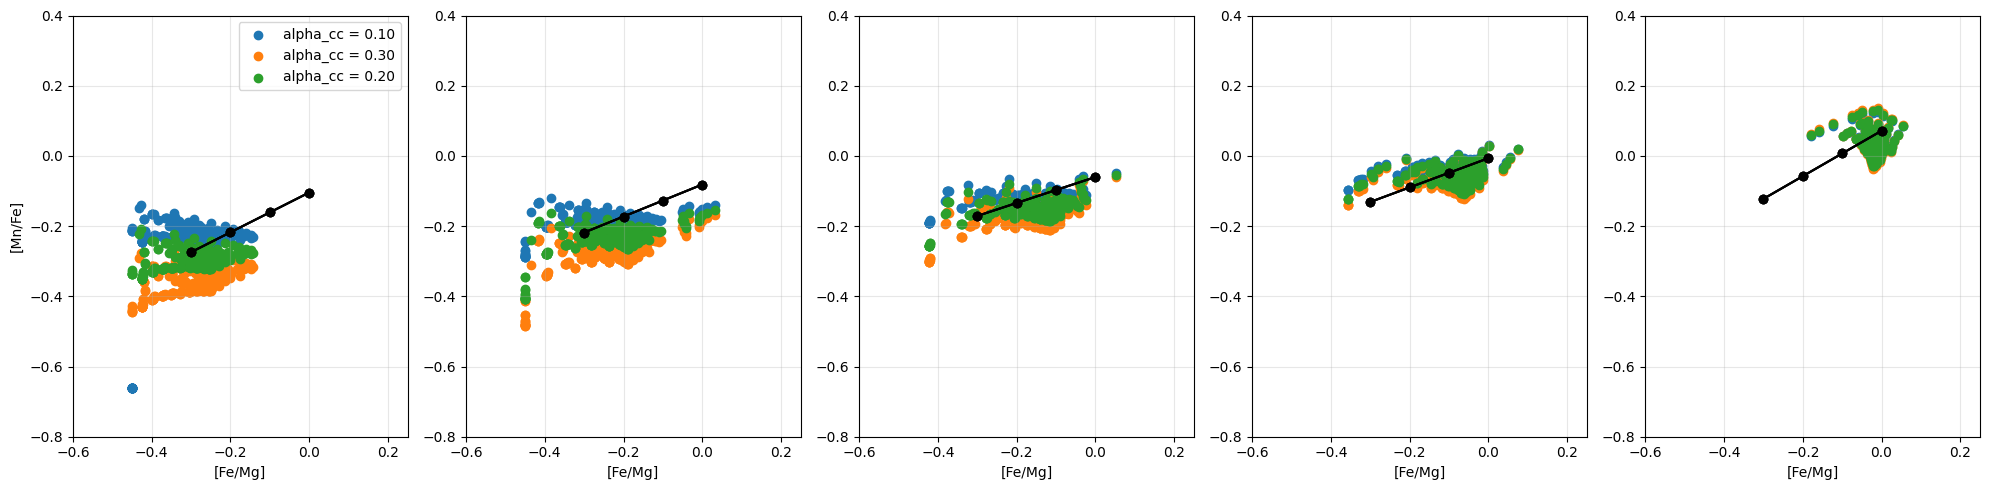

In [84]:
folder_path = "nopenalty_14/"
filepath_list = []
output_dfs = []

for filename in os.listdir(folder_path):
    if filename.startswith("alpha_cc_iter4") and filename.endswith(".csv"):
        filepath_list.append(folder_path+filename)
        df = pd.read_csv(folder_path+filename)
        output_dfs.append(df)


plt.figure(figsize=(20,5))

for i in range(len(output_dfs)):
    model_df = output_dfs[i]
    mg_h_bins = model_df['mg_h_bin'].unique()
    for j in range(len(mg_h_bins)):
        mg_h_bin = mg_h_bins[j]
        model_subset = model_df[np.isclose(model_df['mg_h_bin'], mg_h_bin)]
        data_subset = data[np.isclose(data['mg_h_bin_center'], mg_h_bin)]
        data_line_xs = fe_mg_centers
        data_line_ys = data_subset['slope_mn_fe'].iloc[0] * fe_mg_centers + data_subset['intercept_mn_fe'].iloc[0]
        plt.subplot(1,5,j+1)
        plt.plot(data_line_xs, data_line_ys, marker = 'o', color = 'black')
        plt.scatter(model_subset['fe_mg'], model_subset['mn_fe'], label = f'alpha_cc = {model_subset['alpha_cc'].iloc[0]:.2f}')
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.grid(True, alpha = 0.3)
        plt.xlabel("[Fe/Mg]")
        if j == 0:
            plt.ylabel("[Mn/Fe]")
            plt.legend()

plt.tight_layout()
plt.show()

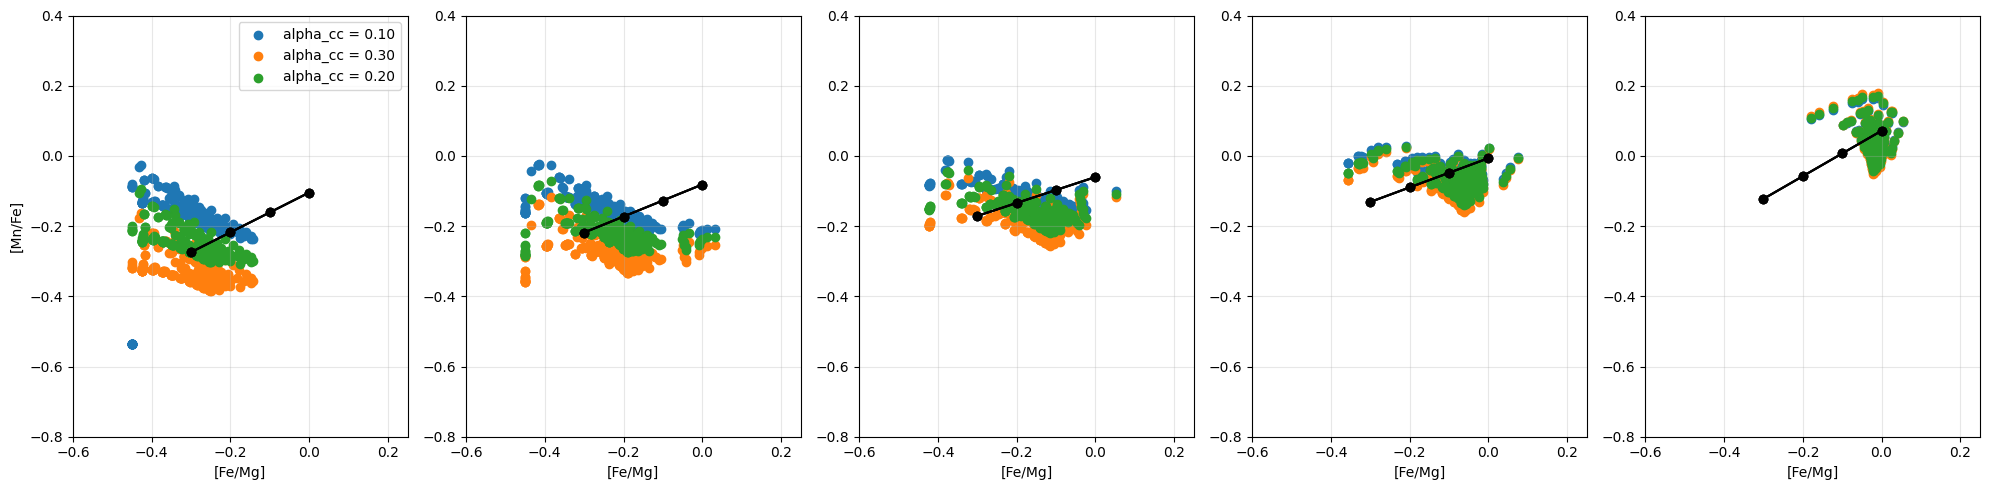

In [85]:
folder_path = "nopenalty_13/"
filepath_list = []
output_dfs = []

for filename in os.listdir(folder_path):
    if filename.startswith("alpha_cc_iter4") and filename.endswith(".csv"):
        filepath_list.append(folder_path+filename)
        df = pd.read_csv(folder_path+filename)
        output_dfs.append(df)


plt.figure(figsize=(20,5))

for i in range(len(output_dfs)):
    model_df = output_dfs[i]
    mg_h_bins = model_df['mg_h_bin'].unique()
    for j in range(len(mg_h_bins)):
        mg_h_bin = mg_h_bins[j]
        model_subset = model_df[np.isclose(model_df['mg_h_bin'], mg_h_bin)]
        data_subset = data[np.isclose(data['mg_h_bin_center'], mg_h_bin)]
        data_line_xs = fe_mg_centers
        data_line_ys = data_subset['slope_mn_fe'].iloc[0] * fe_mg_centers + data_subset['intercept_mn_fe'].iloc[0]
        plt.subplot(1,5,j+1)
        plt.plot(data_line_xs, data_line_ys, marker = 'o', color = 'black')
        plt.scatter(model_subset['fe_mg'], model_subset['mn_fe'], label = f'alpha_cc = {model_subset['alpha_cc'].iloc[0]:.2f}')
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.grid(True, alpha = 0.3)
        plt.xlabel("[Fe/Mg]")
        if j == 0:
            plt.ylabel("[Mn/Fe]")
            plt.legend()

plt.tight_layout()
plt.show()